## XGBoost - Modell

 Besonderheiten XGBoost:
  - Gradient-Boosting-Verfahren auf Basis von Entscheidungsbäumen
  - aber: 
     - viele kleine Bäume statt eines großen
     - erster Baum macht Vorhersage
     - XGBoost betrachtet, wo dieser Baum Fehler macht
     - der nächste Baum wird gezielt darauf trainiert, diesen Fehler zu korrigieren
     - der dritte Baum korrigiert wiederrum die verbleibenden Fehler usw.
     - ==> neue Bäume orientieren sich am Gradienten der Loss Function
  - XGBoost nutzt Regualarisierung
  - XGBoost verwendet Learning Rate + viele Bäume
  - XGBoost kann Missing Values direkt behandeln
  - keine Standardisierung notwendig
  - XGBoost kann komplexe Zusammenhänge erkennen
  - sehr nützlich für Tabular Data

In [1]:
# setup

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb

RANDOM_STATE = 42
N_SPLITS = 5
print("xgboost", xgb.__version__)   # >= 1.6 nötig, >= 2.0 ideal für stabile native categorical

xgboost 3.4.0


In [2]:
# daten laden
def load_porto_seguro():
    bunch = fetch_openml(data_id=42742, as_frame=True, parser="auto")
    df = bunch.frame.copy()
    y = df.pop("target").astype(int)        # Zielspalte ist Kategorie -> 0/1
    return df, y

X_raw, y = load_porto_seguro()
print(X_raw.shape, "| positive rate:", round(float(y.mean()), 4))   

(595212, 57) | positive rate: 0.0364


In [3]:
# Featuregruppierung nach Suffix bzw Präfix 

def column_groups(df):
    cols = list(df.columns)
    bin_cols  = [c for c in cols if c.endswith("_bin")]
    cat_cols  = [c for c in cols if c.endswith("_cat")]
    num_cols  = [c for c in cols if c not in bin_cols and c not in cat_cols]
    calc_cols = [c for c in cols if c.startswith("ps_calc")]   # calc verteilt sich auf bin + num
    return {"bin": bin_cols, "cat": cat_cols, "num": num_cols, "calc": calc_cols}

groups = column_groups(X_raw)
for k, v in groups.items():
    print(f"{k:5s} {len(v)}")

bin   17
cat   14
num   26
calc  20


In [4]:
# dtype preprocessing (NaN bleibt nativ;  cats -> category) 
def prepare_dtypes(df, groups):
    df = df.copy()
    # numerische + binäre Spaltenauf float; NaN bleibt NaN 
    for c in groups["num"] + groups["bin"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # kategoriale Spalten -> pandas category (Voraussetzung für enable_categorical)
    for c in groups["cat"]:
        df[c] = df[c].astype("category")     # inkl. ps_car_11_cat mit ~104 Kategorien, kein One-Hot
    return df

X = prepare_dtypes(X_raw, groups)

# Missing-Count als eigenes Feature: zeilenweise, label-unabhängig -> kein Leakage, darf global sein
X["ps_missing_count"] = X.isna().sum(axis=1).astype("int32")

In [5]:
# meta tablle 

def build_meta(df, groups):
    def grp(c):
        for g in ("ind", "reg", "car", "calc"):
            if f"ps_{g}_" in c:
                return g
        return "other"
    def typ(c):
        if c.endswith("_bin"): return "bin"
        if c.endswith("_cat"): return "cat"
        return "num"
    rows = [{
        "feature": c, "group": grp(c), "type": typ(c),
        "n_missing": int(df[c].isna().sum()),
        "pct_missing": round(float(df[c].isna().mean()) * 100, 2),
        "n_unique": int(df[c].nunique(dropna=True)),
    } for c in df.columns]
    return (pd.DataFrame(rows)
              .sort_values(["group", "type", "feature"])
              .reset_index(drop=True))

meta = build_meta(X, groups)
meta.head(12)

,feature,group,type,n_missing,pct_missing,n_unique
0,ps_calc_15_bin,calc,bin,0,0.0,2
1,ps_calc_16_bin,calc,bin,0,0.0,2
2,ps_calc_17_bin,calc,bin,0,0.0,2
3,ps_calc_18_bin,calc,bin,0,0.0,2
4,ps_calc_19_bin,calc,bin,0,0.0,2
5,ps_calc_20_bin,calc,bin,0,0.0,2
6,ps_calc_01,calc,num,0,0.0,10
7,ps_calc_02,calc,num,0,0.0,10
8,ps_calc_03,calc,num,0,0.0,10
9,ps_calc_04,calc,num,0,0.0,6


In [ ]:
# Feature-Sätze (calc-Experiment + missing-count Toggle) 

def make_feature_list(groups, include_calc=True, include_missing_count=True):
    feats = groups["cat"] + groups["bin"] + groups["num"]
    if not include_calc:
        feats = [c for c in feats if not c.startswith("ps_calc")]
    if include_missing_count:
        feats = feats + ["ps_missing_count"]
    return feats

features_with_calc    = make_feature_list(groups, include_calc=True)
features_without_calc = make_feature_list(groups, include_calc=False)
print("mit calc:", len(features_with_calc), "| ohne calc:", len(features_without_calc))


mit calc: 58 | ohne calc: 38


In [7]:
# CV-Splitter + Gini

def gini_normalized(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1     # direkt vergleichbar zur Baseline (~0.26)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# Modell

def make_model(scale_pos_weight):
    return xgb.XGBClassifier(
        n_estimators=2000,                      # Obergrenze; Early Stopping schneidet ab
        learning_rate=0.05,
        max_depth=4,                            # flach: Signal ist schwach + verrauscht
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.5,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="auc",                      # monoton zu Gini -> Early Stopping stoppt am Gini-Optimum
        early_stopping_rounds=100,              # gehört in den Konstruktor (>= 1.6)
        tree_method="hist",                     # Voraussetzung für native categorical
        enable_categorical=True,                # NaN + category-Spalten werden nativ behandelt
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

In [9]:
# CV-Konfiguration durchrechnen 

from sklearn.model_selection import train_test_split

def run_cv(X, y, features, spw_mode="on", verbose=True):
    Xf = X[features]                              # Indexing erhält den category-dtype
    oof = np.zeros(len(y), dtype=float)
    fold_ginis, best_iters = [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(Xf, y), start=1):
        X_tr, X_va = Xf.iloc[tr_idx], Xf.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # internes Val-Set fürs Early Stopping aus dem Trainingsfold abzweigen
        X_in, X_es, y_in, y_es = train_test_split(
            X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=RANDOM_STATE
        )

        spw = ((y_in == 0).sum() / (y_in == 1).sum()) if spw_mode == "on" else 1.0

        model = make_model(spw)
        model.fit(X_in, y_in, eval_set=[(X_es, y_es)], verbose=False)

        proba = model.predict_proba(X_va)[:, 1]   # nutzt automatisch best_iteration
        oof[va_idx] = proba
        g = gini_normalized(y_va, proba)
        fold_ginis.append(g)
        best_iters.append(model.best_iteration)
        if verbose:
            print(f"  Fold {fold}: gini={g:.4f}  best_iter={model.best_iteration}  spw={spw:.1f}")

    fold_ginis = np.array(fold_ginis)
    oof_gini = gini_normalized(y, oof)
    if verbose:
        print(f"  -> CV {fold_ginis.mean():.4f} ± {fold_ginis.std():.4f} | OOF {oof_gini:.4f}")
    return {"mean": fold_ginis.mean(), "std": fold_ginis.std(),
            "oof_gini": oof_gini, "fold_ginis": fold_ginis,
            "best_iters": best_iters, "oof": oof}

In [10]:
# (calc x scale_pos_weight) --> 2x2-Experiment-Matrix 

experiments = {
    ("with_calc",    "spw_on"):  (features_with_calc,    "on"),
    ("with_calc",    "spw_off"): (features_with_calc,    "off"),
    ("without_calc", "spw_on"):  (features_without_calc, "on"),
    ("without_calc", "spw_off"): (features_without_calc, "off"),
}

results = {}
for (calc_tag, spw_tag), (feats, spw_mode) in experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag}  ({len(feats)} features) ===")
    results[(calc_tag, spw_tag)] = run_cv(X, y, feats, spw_mode=spw_mode)


=== with_calc | spw_on  (58 features) ===
  Fold 1: gini=0.2729  best_iter=164  spw=26.4
  Fold 2: gini=0.2594  best_iter=203  spw=26.4
  Fold 3: gini=0.2677  best_iter=211  spw=26.4
  Fold 4: gini=0.2609  best_iter=152  spw=26.4
  Fold 5: gini=0.2600  best_iter=208  spw=26.4
  -> CV 0.2642 ± 0.0053 | OOF 0.2640

=== with_calc | spw_off  (58 features) ===
  Fold 1: gini=0.2760  best_iter=142  spw=1.0
  Fold 2: gini=0.2606  best_iter=251  spw=1.0
  Fold 3: gini=0.2679  best_iter=129  spw=1.0
  Fold 4: gini=0.2675  best_iter=196  spw=1.0
  Fold 5: gini=0.2588  best_iter=175  spw=1.0
  -> CV 0.2661 ± 0.0061 | OOF 0.2659

=== without_calc | spw_on  (38 features) ===
  Fold 1: gini=0.2689  best_iter=164  spw=26.4
  Fold 2: gini=0.2563  best_iter=226  spw=26.4
  Fold 3: gini=0.2689  best_iter=205  spw=26.4
  Fold 4: gini=0.2588  best_iter=192  spw=26.4
  Fold 5: gini=0.2606  best_iter=195  spw=26.4
  -> CV 0.2627 ± 0.0052 | OOF 0.2626

=== without_calc | spw_off  (38 features) ===
  Fold 1:

In [11]:
# Zusammenfassung + Vergleich zur Baseline

BASELINE_GINI = 0.26

summary = (pd.DataFrame([
        {"calc": c, "scale_pos_weight": s,
         "gini_mean": r["mean"], "gini_std": r["std"], "oof_gini": r["oof_gini"],
         "vs_baseline": r["oof_gini"] - BASELINE_GINI}
        for (c, s), r in results.items()
    ])
    .sort_values("oof_gini", ascending=False)
    .reset_index(drop=True))
summary.round(4)

,calc,scale_pos_weight,gini_mean,gini_std,oof_gini,vs_baseline
0,without_calc,spw_off,0.2673,0.0050,0.2671,0.0071
1,with_calc,spw_off,0.2661,0.0061,0.2659,0.0059
2,with_calc,spw_on,0.2642,0.0053,0.2640,0.0040
3,without_calc,spw_on,0.2627,0.0052,0.2626,0.0026


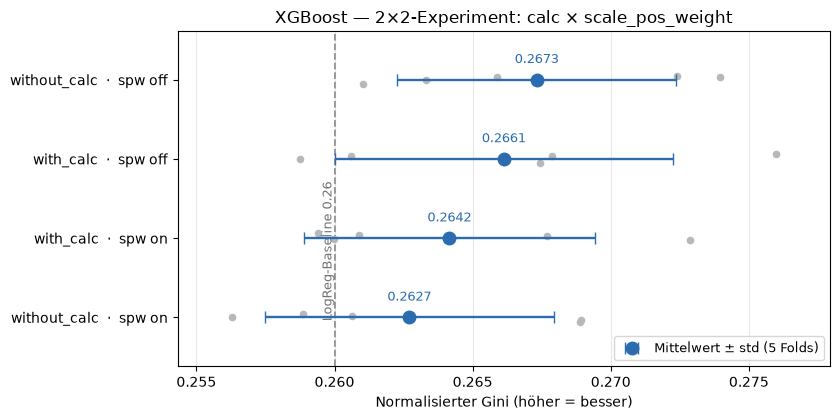

In [12]:
# Visualisierung 

import matplotlib.pyplot as plt

rng = np.random.default_rng(RANDOM_STATE)   # reproduzierbarer Jitter

# nach OOF-Gini sortieren, beste oben
order  = sorted(results.items(), key=lambda kv: kv[1]["oof_gini"], reverse=True)
labels = [f"{c}  ·  {s.replace('spw_', 'spw ')}" for (c, s), _ in order]
means  = np.array([r["mean"] for _, r in order])
stds   = np.array([r["std"]  for _, r in order])
folds  = [r["fold_ginis"] for _, r in order]
y      = np.arange(len(order))[::-1]        # Index 0 (beste) nach oben

fig, ax = plt.subplots(figsize=(8.5, 4.3))

# Baseline
ax.axvline(BASELINE_GINI, ls="--", lw=1.3, color="0.55", zorder=1)
ax.text(BASELINE_GINI, y.min() - 0.05, f"LogReg-Baseline {BASELINE_GINI:.2f} ",
        rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

# einzelne Fold-Ginis -> zeigt die Überlappung zwischen den Konfigs
for yi, fg in zip(y, folds):
    ax.scatter(fg, np.full(len(fg), yi) + rng.uniform(-0.07, 0.07, len(fg)),
               s=20, color="0.72", zorder=2)

# Mittelwert ± std
ax.errorbar(means, y, xerr=stds, fmt="o", ms=9, color="#2b6cb0",
            capsize=4, lw=1.7, zorder=3, label="Mittelwert ± std (5 Folds)")

for yi, m in zip(y, means):
    ax.annotate(f"{m:.4f}", (m, yi), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (höher = besser)")
ax.set_title("XGBoost — 2×2-Experiment: calc × scale_pos_weight")
ax.margins(x=0.10, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()